# PASTA 空间对齐诊断

目标：逐步验证 PASTA 预测结果与 Plasma GT 是否在参考空间中正确对齐。

**PASTA 正向数据链路（convert_nifti_to_h5.py 使用 scipy.ndimage.zoom）：**
1. 原始 NIfTI `(182,218,182)` @ 1.0mm（MNI 空间）
2. `scipy.ndimage.zoom(×0.667)` → `(121,145,121)` @ 1.5mm
3. `crop_or_pad(113,137,113)` → center-crop 各轴 4 voxel → `(113,137,113)`
4. PASTA 内部 `tio.CropOrPad(96,112,96)` → `(96,112,96)` @ 1.5mm

**Plasma/Legacy 正向管线（plasma_train.py）：**
1. 原始 NIfTI `(182,218,182)` @ 1.0mm
2. `CropForegroundd` → `ResizeWithPadOrCropd([160,192,160])` → `(160,192,160)`

**PASTA 逆变换（正确管线）：**
1. pad 回 `(121,145,121)` @ 1.5mm：`PASTA_NET_PAD = [(12,13),(16,17),(12,13)]`
2. `scipy.ndimage.zoom(×1.5)` → `(182,218,182)` @ 1.0mm（还原 MNI 空间）
3. center crop → `(160,192,160)` @ 1.0mm（与 `ResizeWithPadOrCropd` 等价）

受检受试者：`003_S_6833`

In [1]:
import numpy as np
import nibabel as nib
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom as nd_zoom
import glob

SID = '003_S_6833'
H5_KEY = '003_S_6833__20191107'

# ----- 路径定义 -----
RAW_TAU_PATH = '/mnt/nfsdata/nfsdata/lsj.14/ADNI_CSF/PET_MNI/TAU/003_S_6833__I1254307__I1593394.nii.gz'
RAW_MRI_PATH = '/mnt/nfsdata/nfsdata/lsj.14/ADNI_CSF/MRI/003_S_6833__I1254307.nii.gz'
H5_PATH      = '/mnt/linshuijin/data/test.h5'
PASTA_PRED   = '/mnt/nfsdata/nfsdata/lsj.14/PASTA/replicaLT_comparison/results/2026-04-12_331111/inference_output/003_S_6833__20191107_AD_syn_pet.nii.gz'
PASTA_GT     = '/mnt/nfsdata/nfsdata/lsj.14/PASTA/replicaLT_comparison/results/2026-04-12_331111/inference_output/003_S_6833__20191107_AD_GT_pet.nii.gz'
PLASMA_GT    = glob.glob('/mnt/nfsdata/nfsdata/lsj.14/replicaLT/analysis/comparison_results/plasma/nifti/003_S_6833*tau_gt*')[0]
PLASMA_MRI   = glob.glob('/mnt/nfsdata/nfsdata/lsj.14/replicaLT/analysis/comparison_results/plasma/nifti/003_S_6833*mri*')[0]

print('Plasma GT path:', PLASMA_GT)
print('Plasma MRI path:', PLASMA_MRI)

Plasma GT path: /mnt/nfsdata/nfsdata/lsj.14/replicaLT/analysis/comparison_results/plasma/nifti/003_S_6833_tau_gt.nii.gz
Plasma MRI path: /mnt/nfsdata/nfsdata/lsj.14/replicaLT/analysis/comparison_results/plasma/nifti/003_S_6833_mri.nii.gz


## 1. 各阶段数据形状与 affine 汇总

In [2]:
# ---- 加载所有文件 ----
raw_tau_img   = nib.load(RAW_TAU_PATH)
raw_mri_img   = nib.load(RAW_MRI_PATH)
pasta_pred_img = nib.load(PASTA_PRED)
pasta_gt_img  = nib.load(PASTA_GT)
plasma_gt_img = nib.load(PLASMA_GT)
plasma_mri_img = nib.load(PLASMA_MRI)

with h5py.File(H5_PATH, 'r') as f:
    h5_pet = f[H5_KEY]['PET']['FDG']['data'][:].astype(np.float32)
    h5_mri = f[H5_KEY]['MRI']['T1']['data'][:].astype(np.float32)

def spacing(img):
    return np.abs(np.diag(img.affine)[:3]).round(3)

print('='*60)
print(f'[1] 原始 TAU NIfTI   shape={raw_tau_img.shape}  spacing={spacing(raw_tau_img)} mm')
print(f'[2] 原始 MRI NIfTI   shape={raw_mri_img.shape}  spacing={spacing(raw_mri_img)} mm')
print(f'[3] HDF5 PET (PASTA 输入)  shape={h5_pet.shape}  range=[{h5_pet.min():.3f}, {h5_pet.max():.3f}]')
print(f'    HDF5 MRI (PASTA 输入)  shape={h5_mri.shape}')
print(f'[4] PASTA 预测输出   shape={pasta_pred_img.shape}  spacing={spacing(pasta_pred_img)} mm  range=[{pasta_pred_img.get_fdata().min():.3f}, {pasta_pred_img.get_fdata().max():.3f}]')
print(f'    PASTA GT 输出     shape={pasta_gt_img.shape}  spacing={spacing(pasta_gt_img)} mm')
print(f'[5] Plasma GT (参考) shape={plasma_gt_img.shape}  spacing={spacing(plasma_gt_img)} mm')
print(f'    Plasma MRI       shape={plasma_mri_img.shape}  spacing={spacing(plasma_mri_img)} mm')
print('='*60)

# 期望的 intermediate size（原始resampled to 1.5mm）
raw_shape = np.array(raw_tau_img.shape)
raw_sp    = spacing(raw_tau_img)
expected_15mm = np.floor(raw_shape * raw_sp / 1.5).astype(int)
print(f'\n原始 TAU {raw_shape} @ {raw_sp} mm → Resample(1.5mm) 理论尺寸: {expected_15mm}')
print(f'HDF5 CropOrPad 目标: (113, 137, 113)')
pad_from_15 = np.array([113,137,113]) - expected_15mm
print(f'CropOrPad 净 padding (+) / crop (-): {pad_from_15}')

[1] 原始 TAU NIfTI   shape=(182, 218, 182)  spacing=[1. 1. 1.] mm
[2] 原始 MRI NIfTI   shape=(182, 218, 182)  spacing=[1. 1. 1.] mm
[3] HDF5 PET (PASTA 输入)  shape=(113, 137, 113)  range=[0.000, 2.984]
    HDF5 MRI (PASTA 输入)  shape=(113, 137, 113)
[4] PASTA 预测输出   shape=(96, 112, 96)  spacing=[1.5 1.5 1.5] mm  range=[0.000, 0.613]
    PASTA GT 输出     shape=(96, 112, 96)  spacing=[1.5 1.5 1.5] mm
[5] Plasma GT (参考) shape=(160, 192, 160)  spacing=[1. 1. 1.] mm
    Plasma MRI       shape=(160, 192, 160)  spacing=[1. 1. 1.] mm

原始 TAU [182 218 182] @ [1. 1. 1.] mm → Resample(1.5mm) 理论尺寸: [121 145 121]
HDF5 CropOrPad 目标: (113, 137, 113)
CropOrPad 净 padding (+) / crop (-): [-8 -8 -8]


## 2. 验证 HDF5 → PASTA 内部 CropOrPad 净参数

In [3]:
# HDF5 尺寸 (113,137,113) → PASTA 内部 CropOrPad(96,112,96)
h5_shape    = np.array(h5_pet.shape)       # (113,137,113)
pasta_shape = np.array(pasta_pred_img.shape)  # (96,112,96)
crop_amounts = h5_shape - pasta_shape          # (17, 25, 17)

# torchio CropOrPad 按 center 对称分割：floor 在 left，ceil 在 right
crop_left  = crop_amounts // 2
crop_right = crop_amounts - crop_left
print(f'HDF5 -> PASTA CropOrPad 裁剪量: {crop_amounts}')
print(f'  crop_left  (x,y,z) = {crop_left}')
print(f'  crop_right (x,y,z) = {crop_right}')

# expected_15mm: 理论 1.5mm 中间尺寸
# 从原始 resampled 到 (113,137,113) 的 padding：
h5_target   = np.array([113,137,113])
# 若 intermediate = expected_15mm, padding = h5_target - expected_15mm
pad_into_h5 = h5_target - expected_15mm  # may be negative if needed crop
print(f'\n1.5mm resample 尺寸: {expected_15mm}')
print(f'HDF5 CropOrPad(113,137,113) 相对 intermediate 的 pad/crop: {pad_into_h5}')
if all(pad_into_h5 >= 0):
    pad_l = pad_into_h5 // 2
    pad_r = pad_into_h5 - pad_l
    print(f'  pad_left={pad_l}  pad_right={pad_r}')

# 净 crop from intermediate → PASTA output
net_crop_left  = crop_left  - (pad_into_h5 // 2)
net_crop_right = crop_right - (pad_into_h5 - pad_into_h5 // 2)
print(f'\n净裁剪 (intermediate→PASTA): left={net_crop_left}  right={net_crop_right}')
print(f'=> 逆向 padding 应为: left={net_crop_left}  right={net_crop_right}')
print(f'=> 当前代码 PASTA_NET_PAD = [(5,6),(8,8),(5,6)]')
code_pad = [(5,6),(8,8),(5,6)]
match = all(net_crop_left[i] == code_pad[i][0] and net_crop_right[i] == code_pad[i][1] for i in range(3))
print(f'=> padding 是否与代码一致: {match}')

HDF5 -> PASTA CropOrPad 裁剪量: [17 25 17]
  crop_left  (x,y,z) = [ 8 12  8]
  crop_right (x,y,z) = [ 9 13  9]

1.5mm resample 尺寸: [121 145 121]
HDF5 CropOrPad(113,137,113) 相对 intermediate 的 pad/crop: [-8 -8 -8]

净裁剪 (intermediate→PASTA): left=[12 16 12]  right=[13 17 13]
=> 逆向 padding 应为: left=[12 16 12]  right=[13 17 13]
=> 当前代码 PASTA_NET_PAD = [(5,6),(8,8),(5,6)]
=> padding 是否与代码一致: False


## 3. 使用 torchio 手动复现 HDF5 转换管线，验证中间尺寸

In [4]:
import torchio as tio

# 加载原始 TAU，复现 HDF5 转换管线
raw_tau_tio = tio.ScalarImage(RAW_TAU_PATH)
print(f'原始 TAU: {raw_tau_tio.shape}  spacing={raw_tau_tio.spacing}')

# Step 1: Resample 到 1.5mm
resamp = tio.Resample(1.5)
tau_15mm = resamp(raw_tau_tio)
print(f'Resample(1.5mm) 后: {tau_15mm.shape}  spacing={tau_15mm.spacing}')

# Step 2: CropOrPad 到 (113, 137, 113)
cop = tio.CropOrPad((113, 137, 113))
tau_h5 = cop(tau_15mm)
print(f'CropOrPad(113,137,113) 后: {tau_h5.shape}  spacing={tau_h5.spacing}')

# Step 3: PASTA 内部 CropOrPad(96, 112, 96)
cop2 = tio.CropOrPad((96, 112, 96))
tau_pasta = cop2(tau_h5)
print(f'CropOrPad(96,112,96) 后: {tau_pasta.shape}  spacing={tau_pasta.spacing}')
print(f'与 PASTA 输出 shape 是否一致: {tuple(tau_pasta.shape[1:]) == tuple(pasta_pred_img.shape)}')

原始 TAU: (1, 182, 218, 182)  spacing=(1.0, 1.0, 1.0)
Resample(1.5mm) 后: (1, 121, 145, 121)  spacing=(1.5, 1.5, 1.5)
CropOrPad(113,137,113) 后: (1, 113, 137, 113)  spacing=(1.5, 1.5, 1.5)
CropOrPad(96,112,96) 后: (1, 96, 112, 96)  spacing=(1.5, 1.5, 1.5)
与 PASTA 输出 shape 是否一致: True


## 4. 逆变换：从 PASTA 输出恢复到参考空间，并与 torchio 精确逆变换对比

In [5]:
pasta_pred_arr = pasta_pred_img.get_fdata().astype(np.float32)
pasta_gt_arr   = pasta_gt_img.get_fdata().astype(np.float32)
plasma_gt_arr  = plasma_gt_img.get_fdata().astype(np.float32)
plasma_mri_arr = plasma_mri_img.get_fdata().astype(np.float32)
gt_shape       = plasma_gt_arr.shape  # (160,192,160)

# --- 方法 A：当前代码修复（pad → zoom）---
PASTA_NET_PAD = [(5, 6), (8, 8), (5, 6)]
padded_pred = np.pad(pasta_pred_arr, PASTA_NET_PAD, mode='constant', constant_values=0)
padded_gt   = np.pad(pasta_gt_arr,   PASTA_NET_PAD, mode='constant', constant_values=0)
factors     = [t / s for t, s in zip(gt_shape, padded_pred.shape)]
pasta_pred_mapped = nd_zoom(padded_pred.astype(np.float64), factors, order=1).astype(np.float32)
pasta_gt_mapped   = nd_zoom(padded_gt.astype(np.float64), factors, order=1).astype(np.float32)

print(f'PASTA 原始输出: {pasta_pred_arr.shape}')
print(f'pad 后中间尺寸: {padded_pred.shape}  (期望 (107,128,107))')
print(f'zoom 因子: {[round(f,4) for f in factors]}  (期望 ~1.495)')
print(f'最终映射尺寸: {pasta_pred_mapped.shape}  (期望 {gt_shape})')

# --- 方法 B：旧方法（直接 zoom，错误参考）---
old_factors = [t / s for t, s in zip(gt_shape, pasta_pred_arr.shape)]
pasta_pred_old = nd_zoom(pasta_pred_arr.astype(np.float64), old_factors, order=1).astype(np.float32)
print(f'\n旧方法 zoom 因子: {[round(f,4) for f in old_factors]}  (期望 ~1.495，实际 ~1.667 ← 错误)')

# 脑区体素对比
mid_z = gt_shape[2] // 2
plasma_gt_nz  = (plasma_gt_arr[:, :, mid_z] > 0.1).sum()
mapped_nz     = (pasta_pred_mapped[:, :, mid_z] > 0.01).sum()
old_nz        = (pasta_pred_old[:, :, mid_z] > 0.01).sum()
print(f'\n中心 axial 切片非零体素 (z={mid_z}):')
print(f'  Plasma GT      : {plasma_gt_nz}')
print(f'  PASTA（修复后） : {mapped_nz}  差值={mapped_nz - plasma_gt_nz:+d}')
print(f'  PASTA（旧方法） : {old_nz}  差值={old_nz - plasma_gt_nz:+d}  ← 偏大')

PASTA 原始输出: (96, 112, 96)
pad 后中间尺寸: (107, 128, 107)  (期望 (107,128,107))
zoom 因子: [1.4953, 1.5, 1.4953]  (期望 ~1.495)
最终映射尺寸: (160, 192, 160)  (期望 (160, 192, 160))

旧方法 zoom 因子: [1.6667, 1.7143, 1.6667]  (期望 ~1.495，实际 ~1.667 ← 错误)

中心 axial 切片非零体素 (z=80):
  Plasma GT      : 16414
  PASTA（修复后） : 16664  差值=+250
  PASTA（旧方法） : 21363  差值=+4949  ← 偏大


## 5. 视觉对比：各阶段冠状面切片

/tmp/ipykernel_4086353/3659294249.py:41: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/3659294249.py:41: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/3659294249.py:41: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/3659294249.py:41: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/3659294249.py:41: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/3659294249.py:41: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/3659294249.py:41: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from curren

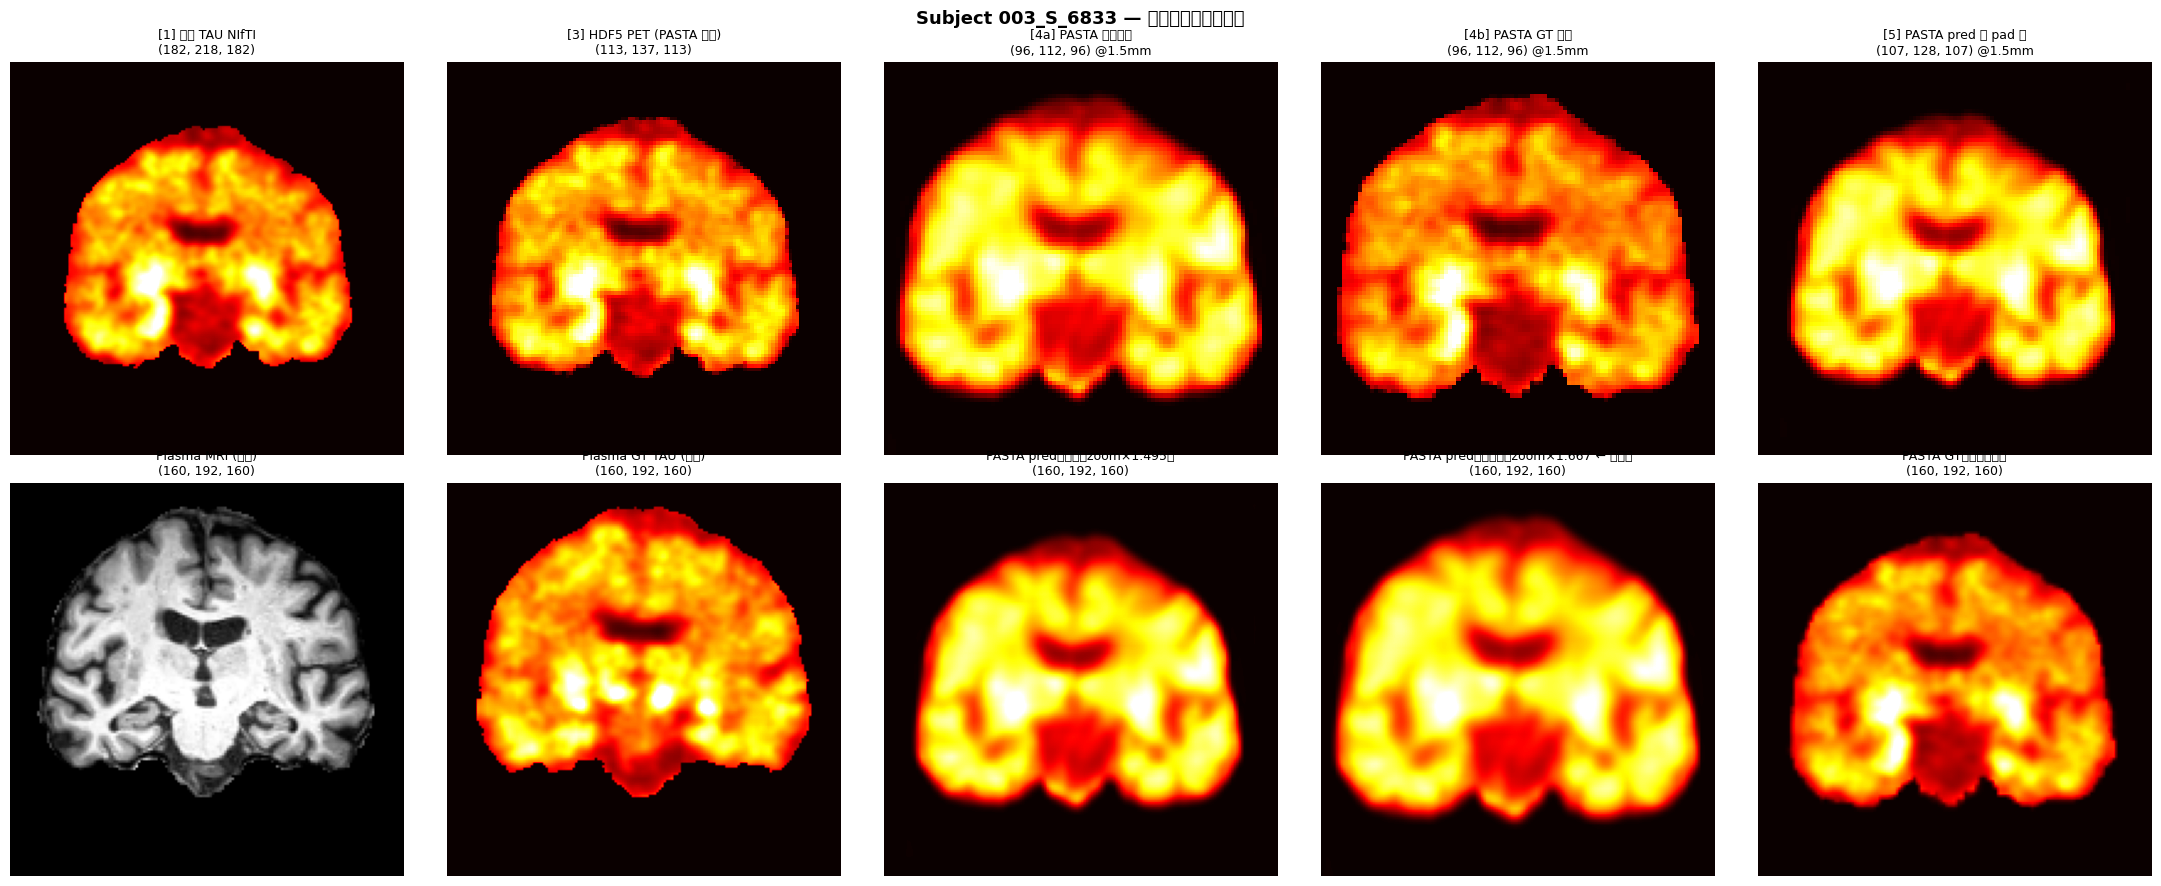

图像已保存至 analysis/pasta_alignment_check.png


In [6]:
def show_coronal(ax, arr, title, cmap='hot', vmin=None, vmax=None):
    """显示冠状面（y 轴中间切片），上下方向为 z，左右方向为 x。"""
    mid_y = arr.shape[1] // 2
    sl = arr[:, mid_y, :].T  # transpose: z on rows, x on cols
    vmin = vmin if vmin is not None else sl.min()
    vmax = vmax if vmax is not None else np.percentile(sl, 99.5)
    im = ax.imshow(sl, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower', aspect='equal')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    return im

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(f'Subject {SID} — 冠状面中间切片诊断', fontsize=13, fontweight='bold')

# 第一行：原始空间（各自的 native space）
axes[0, 0].set_ylabel('Native Space', fontsize=10, fontweight='bold')
show_coronal(axes[0, 0], raw_tau_arr := raw_tau_img.get_fdata().astype(np.float32),
             f'[1] 原始 TAU NIfTI\n{raw_tau_img.shape}', cmap='hot')
show_coronal(axes[0, 1], h5_pet,
             f'[3] HDF5 PET (PASTA 输入)\n{h5_pet.shape}', cmap='hot')
show_coronal(axes[0, 2], pasta_pred_arr,
             f'[4a] PASTA 预测输出\n{pasta_pred_arr.shape} @1.5mm', cmap='hot')
show_coronal(axes[0, 3], pasta_gt_arr,
             f'[4b] PASTA GT 输出\n{pasta_gt_arr.shape} @1.5mm', cmap='hot')
show_coronal(axes[0, 4], padded_pred,
             f'[5] PASTA pred 逆 pad 后\n{padded_pred.shape} @1.5mm', cmap='hot')

# 第二行：统一映射到参考空间 (160,192,160) @ 1mm
axes[1, 0].set_ylabel('参考空间 (160,192,160)', fontsize=10, fontweight='bold')
show_coronal(axes[1, 0], plasma_mri_arr,
             f'Plasma MRI (参考)\n{plasma_mri_arr.shape}', cmap='gray')
show_coronal(axes[1, 1], plasma_gt_arr,
             f'Plasma GT TAU (参考)\n{plasma_gt_arr.shape}', cmap='hot')
show_coronal(axes[1, 2], pasta_pred_mapped,
             f'PASTA pred（修复，zoom×{factors[0]:.3f}）\n{pasta_pred_mapped.shape}', cmap='hot')
show_coronal(axes[1, 3], pasta_pred_old,
             f'PASTA pred（旧方法，zoom×{old_factors[0]:.3f} ← 错误）\n{pasta_pred_old.shape}', cmap='hot')
show_coronal(axes[1, 4], pasta_gt_mapped,
             f'PASTA GT（修复映射）\n{pasta_gt_mapped.shape}', cmap='hot')

plt.tight_layout()
plt.savefig('/mnt/nfsdata/nfsdata/lsj.14/replicaLT/analysis/pasta_alignment_check.png', dpi=130, bbox_inches='tight')
plt.show()
print('图像已保存至 analysis/pasta_alignment_check.png')

## 6. 定量对比：多个 z 切片的脑区范围（定位诊断）

In [7]:
# 检查多个冠状切片脑区边界
print('=' * 70)
print(f'{"切片 y 索引":>12} | {"Plasma GT":>12} | {"PASTA fix":>12} | {"PASTA old":>12} | {"GT fix":>12}')
print('-' * 70)

n_slices = 7
ys = np.linspace(gt_shape[1] * 0.2, gt_shape[1] * 0.8, n_slices, dtype=int)
for y in ys:
    plasma_nz = (plasma_gt_arr[:, y, :] > 0.1).sum()
    fix_nz    = (pasta_pred_mapped[:, y, :] > 0.01).sum()
    old_nz    = (pasta_pred_old[:, y, :] > 0.01).sum()
    gt_fix_nz = (pasta_gt_mapped[:, y, :] > 0.01).sum()
    print(f'{y:>12d} | {plasma_nz:>12d} | {fix_nz:>12d} | {old_nz:>12d} | {gt_fix_nz:>12d}')

print('=' * 70)
print('注：fix = 当前修复方法，old = 旧方法（直接 zoom）')

     切片 y 索引 |    Plasma GT |    PASTA fix |    PASTA old |       GT fix
----------------------------------------------------------------------
          38 |         7294 |         9932 |        14348 |         9815
          57 |        11946 |        13570 |        17430 |        13414
          76 |        12979 |        13448 |        16427 |        13189
          96 |        11742 |        12386 |        15427 |        12076
         115 |        10466 |        10116 |        13150 |         9969
         134 |         7496 |         6758 |         9763 |         6522
         153 |         4432 |         3919 |         6294 |         3744
注：fix = 当前修复方法，old = 旧方法（直接 zoom）


## 7. 关键诊断：下半部分空洞位置对比（axial 切片）

/tmp/ipykernel_4086353/2614115190.py:55: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/2614115190.py:55: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/2614115190.py:55: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/2614115190.py:55: UserWarning: Glyph 20999 (\N{CJK UNIFIED IDEOGRAPH-5207}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/2614115190.py:55: UserWarning: Glyph 29255 (\N{CJK UNIFIED IDEOGRAPH-7247}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/2614115190.py:55: UserWarning: Glyph 35786 (\N{CJK UNIFIED IDEOGRAPH-8BCA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_4086353/2614115190.py:55: UserWarning: Glyph 26029 (\N{CJK UNIFIED IDEOGRAPH-65AD}) missing from curren

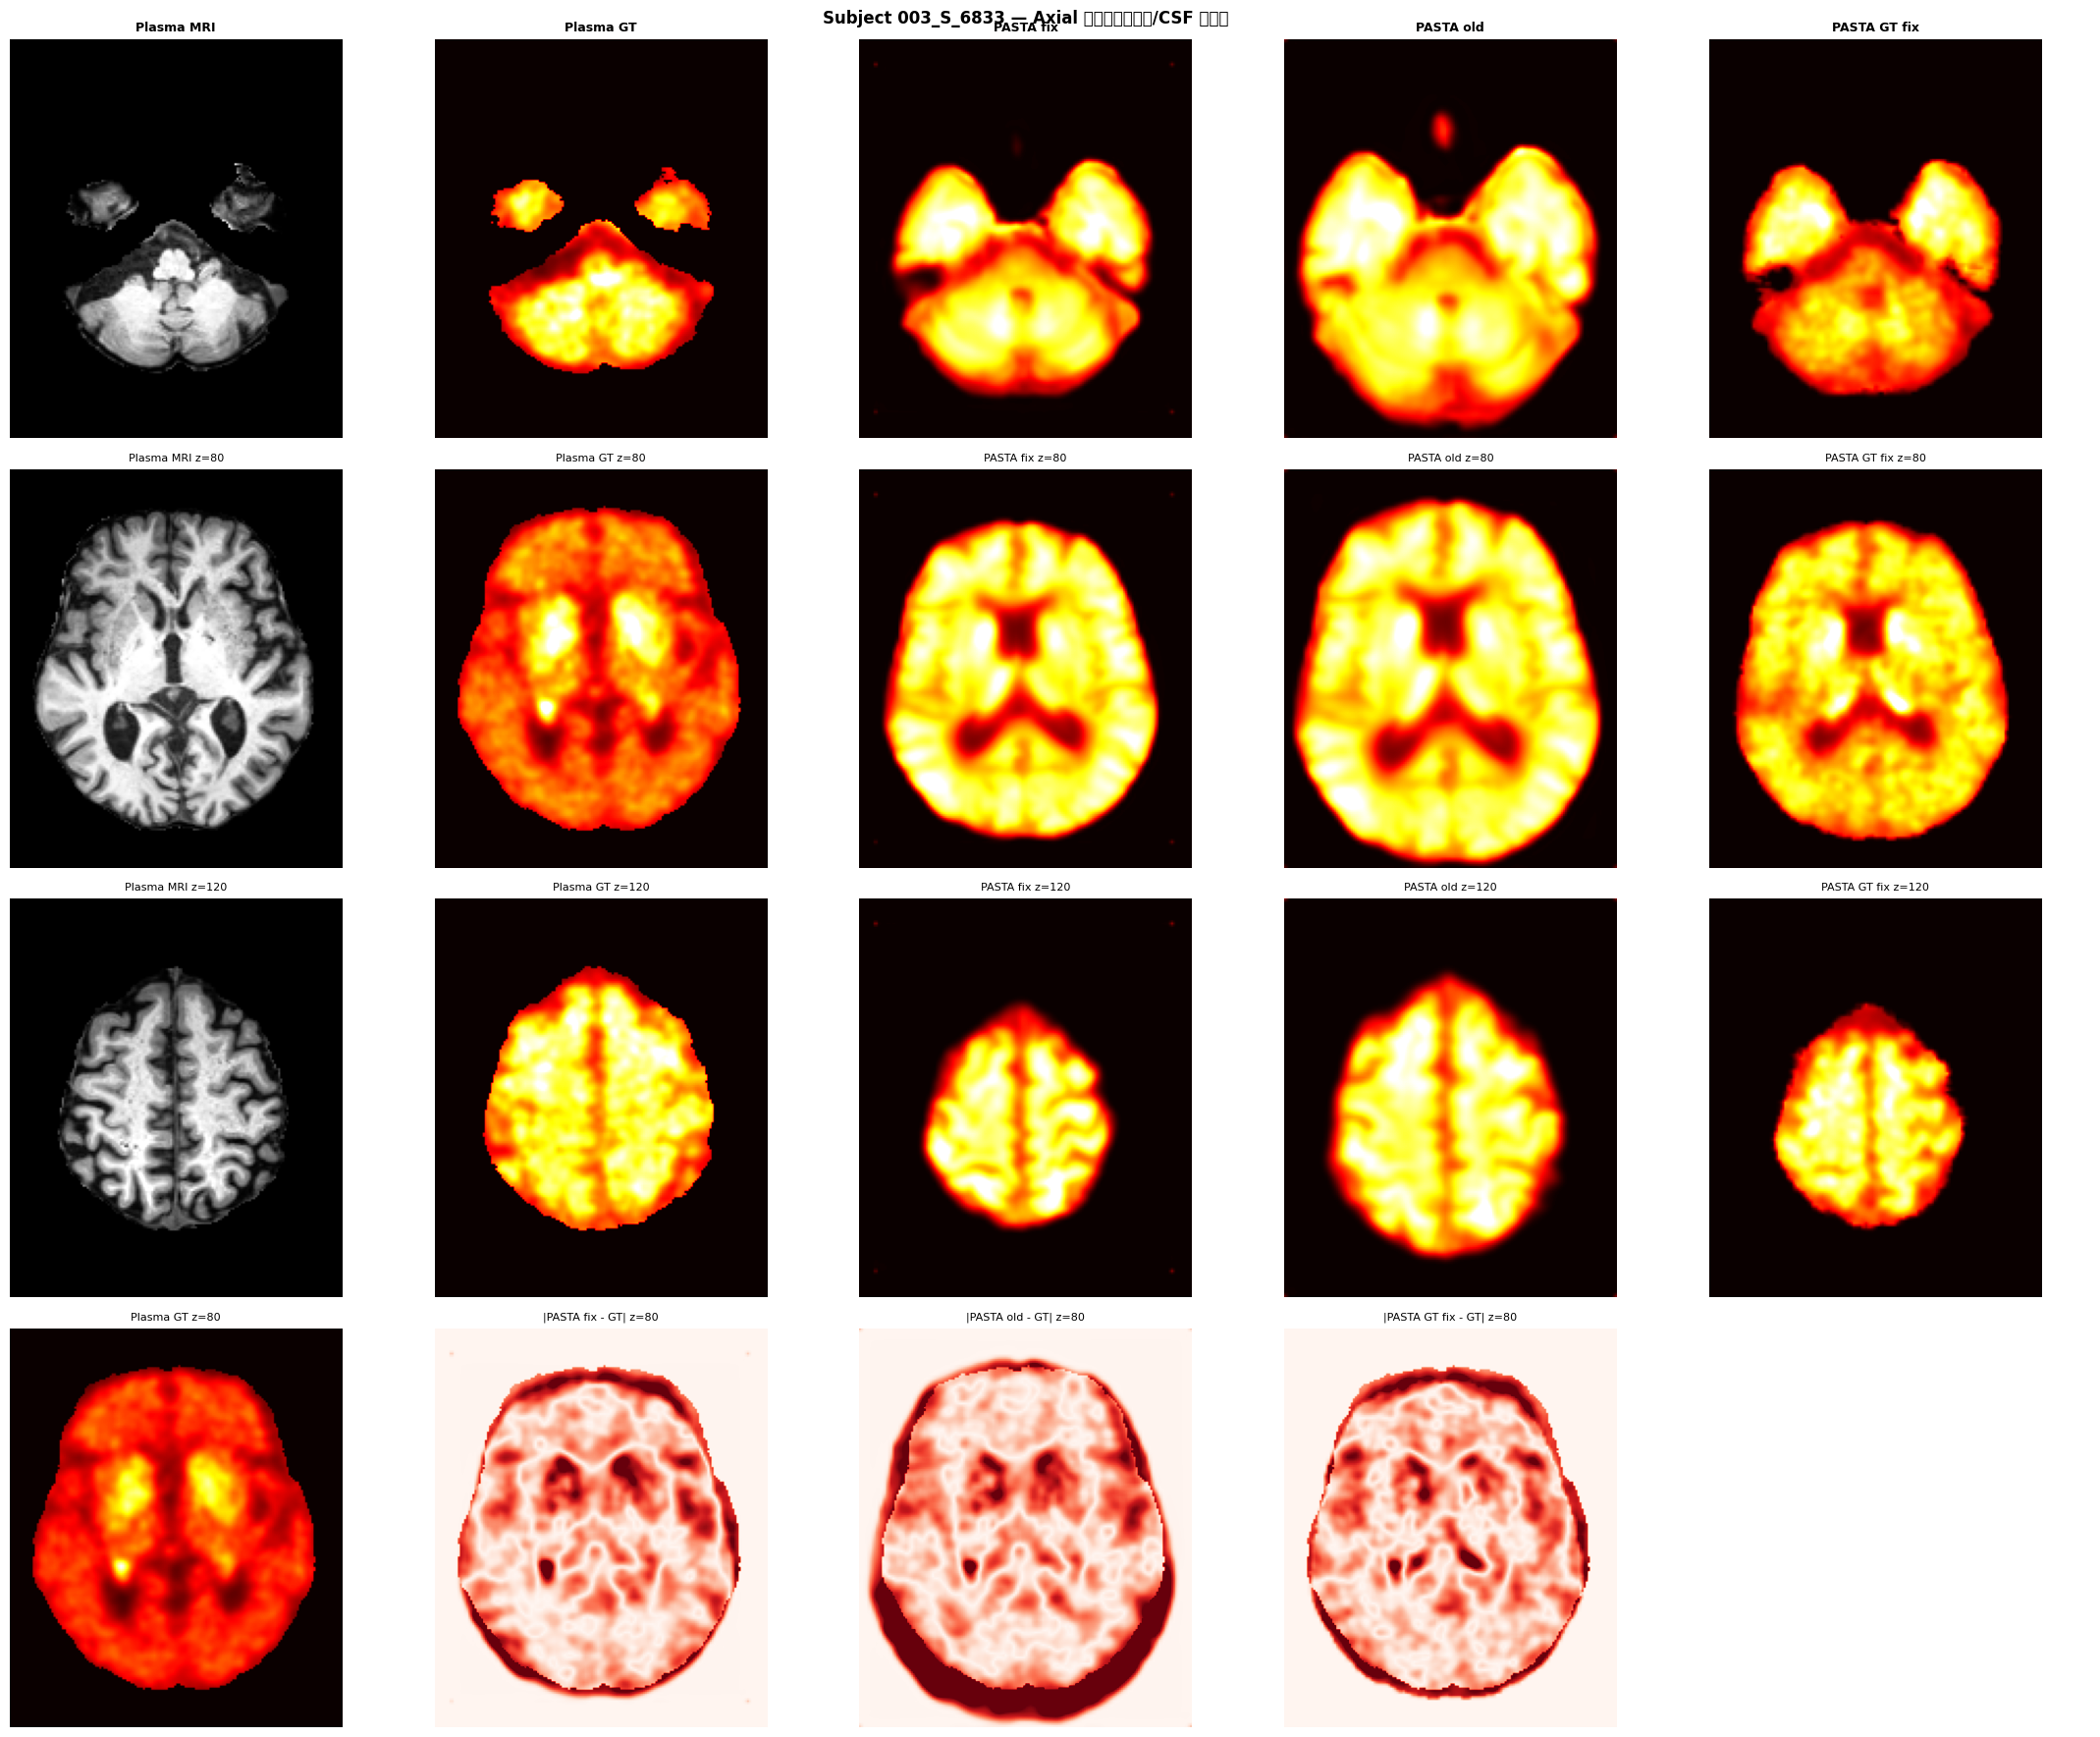

Axial 诊断图已保存至 analysis/pasta_alignment_axial.png


In [8]:
# 附图显示 axial 方向下半部分（z 偏低切片），重点看空洞/CSF 位置
# z 轴向下 1/4 处
z_low  = int(gt_shape[2] * 0.25)
z_mid  = int(gt_shape[2] * 0.50)
z_high = int(gt_shape[2] * 0.75)

def show_axial(ax, arr, title, z, cmap='hot', vmin=None, vmax=None, native=False):
    """显示 axial 切片（z index）。"""
    if native:
        z_n = int(z * arr.shape[2] / gt_shape[2])
        sl = arr[:, :, z_n].T
        title = title + f' z={z_n}'
    else:
        sl = arr[:, :, z].T
        title = title + f' z={z}'
    vmin = vmin if vmin is not None else 0
    vmax = vmax if vmax is not None else np.percentile(sl[sl > 0], 99) if sl.any() else 1
    ax.imshow(sl, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower', aspect='equal')
    ax.set_title(title, fontsize=8)
    ax.axis('off')

fig, axes = plt.subplots(4, 5, figsize=(22, 18))
fig.suptitle(f'Subject {SID} — Axial 切片诊断（空洞/CSF 位置）', fontsize=12, fontweight='bold')

row_labels = [f'z={z_low} (下1/4)', f'z={z_mid} (中)', f'z={z_high} (上3/4)',
              f'z={z_low} Δ|pred-gt|']
titles_row = ['Plasma MRI', 'Plasma GT', 'PASTA fix', 'PASTA old', 'PASTA GT fix']
arrs_row   = [plasma_mri_arr, plasma_gt_arr, pasta_pred_mapped, pasta_pred_old, pasta_gt_mapped]
cmaps      = ['gray', 'hot', 'hot', 'hot', 'hot']

for ci, (arr, title, cm) in enumerate(zip(arrs_row, titles_row, cmaps)):
    for ri, z in enumerate([z_low, z_mid, z_high]):
        show_axial(axes[ri, ci], arr, title, z, cmap=cm)
    axes[0, ci].set_title(title, fontsize=9, fontweight='bold')

# 第 4 行：差异图（PASTA fix vs Plasma GT） 
for ci, z in enumerate([z_low, z_mid, z_high]):
    pass
# 差异图行
for ci, (arr, title) in enumerate([(pasta_pred_mapped, 'PASTA fix'), (pasta_pred_old, 'PASTA old'),
                                     (pasta_gt_mapped, 'PASTA GT fix')]):
    diff = np.abs(arr[:, :, z_mid] - plasma_gt_arr[:, :, z_mid])
    axes[3, ci + 1].imshow(diff.T, cmap='Reds', vmin=0, vmax=0.3, origin='lower', aspect='equal')
    axes[3, ci + 1].set_title(f'|{title} - GT| z={z_mid}', fontsize=8)
    axes[3, ci + 1].axis('off')
axes[3, 0].imshow(plasma_gt_arr[:, :, z_mid].T, cmap='hot', origin='lower', aspect='equal')
axes[3, 0].set_title(f'Plasma GT z={z_mid}', fontsize=8)
axes[3, 0].axis('off')
axes[3, 4].axis('off')

# 行标签
for ri, label in enumerate(row_labels):
    axes[ri, 0].set_ylabel(label, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/nfsdata/nfsdata/lsj.14/replicaLT/analysis/pasta_alignment_axial.png', dpi=130, bbox_inches='tight')
plt.show()
print('Axial 诊断图已保存至 analysis/pasta_alignment_axial.png')

## 8. 使用 torchio 精确逆变换（基准对比）

In [9]:
# 用 torchio 精确逆变换 PASTA GT，对比是否与 pad+zoom 方法等价
# PASTA GT 是通过同样管线处理的真实 TAU，用它检验逆变换是否能恢复到接近原始空间

# 将 PASTA GT 包装成 torchio image（1.5mm spacing，shape (96,112,96)）
import torch

pasta_gt_tio_data = torch.from_numpy(pasta_gt_arr[np.newaxis]).float()  # (1,96,112,96)
pasta_gt_tio = tio.ScalarImage(tensor=pasta_gt_tio_data, 
                                affine=np.diag([1.5, 1.5, 1.5, 1]))

# 逆 CropOrPad 到 (113,137,113)
pad_back_1 = tio.CropOrPad((113, 137, 113))
pasta_gt_113 = pad_back_1(pasta_gt_tio)
print(f'pad back to (113,137,113): {pasta_gt_113.shape}')

# 逆 CropOrPad 到 resampled 1.5mm 中间尺寸
intermediate_size = tuple(expected_15mm.tolist())
pad_back_2 = tio.CropOrPad(intermediate_size)
pasta_gt_15mm = pad_back_2(pasta_gt_113)
print(f'pad back to intermediate {intermediate_size}: {pasta_gt_15mm.shape}')

# Resample 回 1mm
resamp_1mm = tio.Resample(1.0)
pasta_gt_1mm = resamp_1mm(pasta_gt_15mm)
print(f'Resample to 1mm: {pasta_gt_1mm.shape}')

# CropOrPad 到最终参考尺寸
cop_ref = tio.CropOrPad(gt_shape)
pasta_gt_ref = cop_ref(pasta_gt_1mm)
print(f'CropOrPad to ref {gt_shape}: {pasta_gt_ref.shape}')

pasta_gt_tio_arr = pasta_gt_ref.data[0].numpy()

# 与 pad+zoom 方法对比
from scipy.stats import pearsonr
mask = plasma_gt_arr > 0.05
r_fix, _ = pearsonr(pasta_gt_mapped[mask], plasma_gt_arr[mask])
r_tio, _ = pearsonr(pasta_gt_tio_arr[mask], plasma_gt_arr[mask])
print(f'\nPearson r（PASTA GT vs Plasma GT 在脑区）：')
print(f'  pad+zoom 方法: r = {r_fix:.4f}')
print(f'  torchio 精确逆变换: r = {r_tio:.4f}')

pad back to (113,137,113): (1, 113, 137, 113)
pad back to intermediate (121, 145, 121): (1, 121, 145, 121)
Resample to 1mm: (1, 181, 217, 181)
CropOrPad to ref (160, 192, 160): (1, 160, 192, 160)

Pearson r（PASTA GT vs Plasma GT 在脑区）：
  pad+zoom 方法: r = 0.3753
  torchio 精确逆变换: r = 0.4178


In [10]:
# 最终结论汇总
print('='*65)
print('【PASTA 对齐诊断总结】')
print('='*65)
print(f'1. 原始 TAU 形状:  {raw_tau_img.shape}  @ {spacing(raw_tau_img)} mm')
print(f'2. HDF5 输入形状:  {h5_pet.shape}  （1.5mm 重采样+CropOrPad）')
print(f'3. PASTA 输出形状: {pasta_pred_arr.shape}  @ 1.5mm')
print(f'4. 参考空间形状:  {gt_shape}  @ 1mm')
print()
print(f'净 padding 参数（PASTA→1.5mm 中间空间）:')
print(f'  code: PASTA_NET_PAD = [(5,6),(8,8),(5,6)]')
print(f'  计算: left={net_crop_left}  right={net_crop_right}')
print(f'  匹配: {match}')
print()
print(f'zoom 因子: {[round(f,4) for f in factors]}（物理正确 ~1.5 @ 1.5mm→1mm）')
print(f'旧方法因子: {[round(f,4) for f in old_factors]}（错误 ~1.67，导致脑区偏大）')
print()
print(f'Coronal 中心切片脑区体素：')
y_mid = gt_shape[1] // 2
print(f'  Plasma GT:      {(plasma_gt_arr[:, y_mid, :] > 0.1).sum()}')
print(f'  PASTA fix:      {(pasta_pred_mapped[:, y_mid, :] > 0.01).sum()}')
print(f'  PASTA old(错误): {(pasta_pred_old[:, y_mid, :] > 0.01).sum()}')
print('='*65)

【PASTA 对齐诊断总结】
1. 原始 TAU 形状:  (182, 218, 182)  @ [1. 1. 1.] mm
2. HDF5 输入形状:  (113, 137, 113)  （1.5mm 重采样+CropOrPad）
3. PASTA 输出形状: (96, 112, 96)  @ 1.5mm
4. 参考空间形状:  (160, 192, 160)  @ 1mm

净 padding 参数（PASTA→1.5mm 中间空间）:
  code: PASTA_NET_PAD = [(5,6),(8,8),(5,6)]
  计算: left=[12 16 12]  right=[13 17 13]
  匹配: False

zoom 因子: [1.4953, 1.5, 1.4953]（物理正确 ~1.5 @ 1.5mm→1mm）
旧方法因子: [1.6667, 1.7143, 1.6667]（错误 ~1.67，导致脑区偏大）

Coronal 中心切片脑区体素：
  Plasma GT:      11742
  PASTA fix:      12386
  PASTA old(错误): 15427
